# ML_Alt_CNN — 1-D CNN for EMI Corrosion Mass-Loss Prediction

Trains a 1-D Convolutional Neural Network on baseline-relative BVD circuit
parameters to predict cumulative corrosion mass loss.
Uses Leave-One-Sample-Out (LOO) cross-validation across three steel probe samples.

How to run:
  0. Make sure a BVD fit has been saved, one can easily be generated on example data using BVD_AllSamples.ipynb
  1. Adjust DATE_START / DATE_END in the "Load BVD Parameters" section (section 4)
  2. Optionally edit FEATURE_COLS, TRAIN_SAMPLES/VAL_SAMPLES, and training
     hyperparameters (LR, WD, etc.) in sections 9 and 11
  3. Run all cells top-to-bottom — LOO training and evaluation run automatically

# 1. Imports

In [17]:
# ============================================================
# Author : Mads Kofod Dahl
# License: MIT License (2026)
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import torch
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import torch.nn as nn
import torch.optim as optim

plt.rcParams['figure.figsize'] = (25, 20)
plt.rcParams['font.size'] = 14
plt.rcParams['figure.dpi'] = 600


# 2. Load Data

In [18]:
uptime_df = pd.read_csv("Corrosion_Dataset/uptime.csv")

mass_loss_df = pd.read_csv("Corrosion_Dataset/mass_loss.csv")

# 3. Sample Weights
Samples were weighed periodically to calibrate Faraday's law mass-loss estimates.


In [19]:
# Read and plot delta weight loss over time
weight_file_path = "Corrosion_Dataset/SampleWeights.xlsx"

# Read the Excel file
weight_data = pd.read_excel(weight_file_path)

# Convert date format from DDMMYYYY to proper datetime
weight_data['Date_parsed'] = pd.to_datetime(weight_data['Date'].astype(str), format='%d%m%Y')

# Calculate delta weight loss relative to initial measurements
initial_weights = weight_data.iloc[0]  # First row as initial weights

# Calculate weight loss for each sample (initial - current)
weight_data['Sample0_loss'] = initial_weights['Sample0'] - weight_data['Sample0']
weight_data['Sample5_loss'] = initial_weights['Sample5'] - weight_data['Sample5']
weight_data['Sample10_loss'] = initial_weights['Sample10'] - weight_data['Sample10']

# Colors for consistency with other plots
colors = ['blue', 'red', 'green']
sample_names = ['Sample0', 'Sample5', 'Sample10']

# 4. Load BVD Parameters & Apply Date Filtering

Physics basis — BVD quantities as corrosion proxies:
  L1   ∝ acoustic mass      → accumulates as corrosion product builds up
  R1   ∝ mechanical damping → rises as surface roughens
  1/C1 ∝ stiffness          → shifts as corrosion alters elastic properties
  f_r  = 1/(2π√(L1·C1))   → resonant frequency drops with mass increase



In [20]:
import warnings
warnings.filterwarnings('ignore')

# -- Date window for dataset filtering -----------------------------------------
DATE_START = "2026-02-12"

DATE_END = "2026-03-30"  # inclusive day

START_DATE = pd.Timestamp(DATE_START)
END_DATE = pd.Timestamp(DATE_END)
END_DATE_EXCLUSIVE = END_DATE + pd.Timedelta(days=1)

# -- 1. Load BVD parameters -----------------------------------------------------
bvd_path = "BVD_Fits/fitted_bvd_params.csv"

bvd_df = pd.read_csv(bvd_path, parse_dates=['timestamp'])

# Filter out diverged fits — keep only rows with a positive R² on the real part
bvd_df = bvd_df[bvd_df['r2_real'] > 0.1].copy()

# Filter to date window
bvd_df = bvd_df[
    (bvd_df['timestamp'] >= START_DATE) &
    (bvd_df['timestamp'] < END_DATE_EXCLUSIVE)
].copy()

bvd_df['fit_quality'] = bvd_df['r2_real']          # quality feature
bvd_df['Date'] = bvd_df['timestamp'].dt.date

# Days elapsed since first measurement
t0 = bvd_df['timestamp'].min()
bvd_df['time_days'] = (bvd_df['timestamp'] - t0).dt.total_seconds() / 86400

print(f"Using date window: {START_DATE.date()} to {END_DATE.date()} (inclusive)")
print(f"BVD params after filtering: {len(bvd_df)} rows  (samples: {bvd_df['sample'].unique()})")
bvd_df[['sample', 'timestamp', 'R0', 'R1', 'L1', 'C1', 'fit_quality']].head(6)


Using date window: 2026-02-12 to 2026-03-30 (inclusive)
BVD params after filtering: 68 rows  (samples: ['sample_10' 'sample_0' 'sample_5'])


,sample,timestamp,R0,R1,L1,C1,fit_quality
0,sample_10,2026-02-12 16:23:12,247.435251,1281.264630,0.02,2.442472e-11,0.693735
1,sample_0,2026-02-13 18:41:47,229.838661,364.588372,0.02,3.363535e-11,0.978528
2,sample_10,2026-02-13 18:41:47,227.121771,1534.467032,0.02,2.476123e-11,0.732234
3,sample_0,2026-02-16 17:28:36,195.365169,309.914174,0.02,3.361283e-11,0.797047
4,sample_10,2026-02-16 17:28:36,236.047876,1456.424490,0.02,2.466939e-11,0.726684
5,sample_0,2026-02-17 17:56:33,175.828729,278.946483,0.02,3.364651e-11,0.863564


In [21]:
# -- Use Faraday's law mass loss directly -----------------------------------
sample_map = {
    'sample_0':  ('Sample0',  'Sample0_loss'),
    'sample_5':  ('Sample5',  'Sample5_loss'),
    'sample_10': ('Sample10', 'Sample10_loss'),
}

real_mass_loss = pd.read_csv("Corrosion_Dataset/calibrated_mass_loss.csv")

# calibrated_df = mass_loss_df.copy()
calibrated_df = real_mass_loss

calibrated_df = calibrated_df.rename(columns={'Sample': 'sample_key'})
calibrated_df['Date'] = pd.to_datetime(calibrated_df['Date'])

# Apply the same date window as BVD data
calibrated_df = calibrated_df[
    (calibrated_df['Date'] >= START_DATE) &
    (calibrated_df['Date'] < END_DATE_EXCLUSIVE)
].copy()

calibrated_df['Date'] = calibrated_df['Date'].dt.date

print(f"Mass-loss rows in date window: {len(calibrated_df)}")
calibrated_df.head(6)


Mass-loss rows in date window: 48


,Date,sample_key,Cumulative_Mass_Loss_g,Cumulative_Mass_Loss_g_piecewise_cal
0,2026-02-13,sample_0,1.043153,0.000000
1,2026-02-16,sample_0,1.982398,1.159989
2,2026-02-17,sample_0,3.020307,2.441832
3,2026-02-18,sample_0,4.054631,3.719246
4,2026-02-19,sample_0,5.002593,4.890000
5,2026-02-20,sample_0,5.687909,5.425405


In [22]:
# ── Merge BVD params ↔ calibrated mass-loss ──────────────────────────────

merged_df = pd.merge(
    bvd_df,
    calibrated_df[['Date', 'sample_key', 'Cumulative_Mass_Loss_g_piecewise_cal']],
    left_on=['Date', 'sample'],
    right_on=['Date', 'sample_key'],
    how='inner'
).sort_values('timestamp').reset_index(drop=True)

print(f"Merged dataset: {len(merged_df)} rows, {merged_df['sample'].nunique()} samples")
print(f"Date range: {merged_df['timestamp'].min().date()} → {merged_df['timestamp'].max().date()}")
merged_df[['sample', 'timestamp', 'time_days', 'R0', 'C0', 'R1', 'L1', 'C1',
           'fit_quality', 'Cumulative_Mass_Loss_g_piecewise_cal']].head(8)



Merged dataset: 46 rows, 3 samples
Date range: 2026-02-13 → 2026-03-25


,sample,timestamp,time_days,R0,C0,R1,L1,C1,fit_quality,Cumulative_Mass_Loss_g_piecewise_cal
0,sample_0,2026-02-13 18:41:47,1.096238,229.838661,1.970542e-09,364.588372,0.02,3.363535e-11,0.978528,0.000000
1,sample_10,2026-02-13 18:41:47,1.096238,227.121771,1.017097e-09,1534.467032,0.02,2.476123e-11,0.732234,0.000000
2,sample_0,2026-02-16 17:28:36,4.045417,195.365169,2.185295e-09,309.914174,0.02,3.361283e-11,0.797047,1.159989
3,sample_10,2026-02-16 17:28:36,4.045417,236.047876,1.057933e-09,1456.424490,0.02,2.466939e-11,0.726684,1.217535
4,sample_0,2026-02-17 17:56:33,5.064826,175.828729,2.248742e-09,278.946483,0.02,3.364651e-11,0.863564,2.441832
5,sample_5,2026-02-17 17:56:33,5.064826,775.359473,3.034698e-09,664.308215,0.02,3.443551e-11,0.978461,2.536244
6,sample_10,2026-02-17 17:56:33,5.064826,181.996633,8.356119e-10,2100.025934,0.02,2.501020e-11,0.767262,2.551825
7,sample_0,2026-02-18 18:01:37,6.068345,158.246641,2.097156e-09,281.266976,0.02,3.375734e-11,0.921071,3.719246



# 5. Feature Engineering

Compute per-sample baseline-relative changes so the model focuses on
corrosion-driven drift rather than absolute sensor offsets.
Model inputs are delta and rel changes against each sample's initial state.

In [23]:
# ── Simplified feature engineering (only columns used by the model) ───────
merged_df_eng = merged_df.copy().sort_values(['sample', 'timestamp']).reset_index(drop=True)

# Keep baseline + delta/relative only for required channels
for col in ['R0', 'C0', 'R1', 'L1', 'C1']:
    merged_df_eng[f'{col}_0'] = merged_df_eng.groupby('sample')[col].transform('first')
    merged_df_eng[f'delta_{col}'] = merged_df_eng[col] - merged_df_eng[f'{col}_0']
    merged_df_eng[f'rel_{col}'] = (
        merged_df_eng[f'delta_{col}'] / (merged_df_eng[f'{col}_0'].abs() + 1e-30)
    )

# Keep chronological time feature
t0 = merged_df_eng['timestamp'].min()
merged_df_eng['time_days'] = (merged_df_eng['timestamp'] - t0).dt.total_seconds() / 86400

merged_df_eng = merged_df_eng.sort_values('timestamp').reset_index(drop=True)

print(f"Dataset: {len(merged_df_eng)} rows, {merged_df_eng['sample'].nunique()} samples")
print("\nActive features (first 9 rows):")
print(merged_df_eng[['sample', 'timestamp', 'rel_R0', 'rel_C0', 'rel_R1', 'rel_L1', 'rel_C1',
                     'Cumulative_Mass_Loss_g_piecewise_cal']].to_string(index=False, max_rows=9))


Dataset: 46 rows, 3 samples

Active features (first 9 rows):
   sample           timestamp    rel_R0    rel_C0    rel_R1        rel_L1    rel_C1  Cumulative_Mass_Loss_g_piecewise_cal
 sample_0 2026-02-13 18:41:47  0.000000  0.000000  0.000000  0.000000e+00  0.000000                              0.000000
sample_10 2026-02-13 18:41:47  0.000000  0.000000  0.000000  0.000000e+00  0.000000                              0.000000
sample_10 2026-02-16 17:28:36  0.039301  0.040149 -0.050860  0.000000e+00 -0.003709                              1.217535
 sample_0 2026-02-16 17:28:36 -0.149990  0.108982 -0.149961 -7.780427e-08 -0.000670                              1.159989
      ...                 ...       ...       ...       ...           ...       ...                                   ...
sample_10 2026-03-24 16:15:43 -0.190267 -0.205780  0.481001 -1.229158e-06  0.098712                             40.663120
sample_10 2026-03-25 14:20:59 -0.134682 -0.178360  0.436743 -1.307413e-06  0.103157  


## 6. Data Augmentation
Increases dataset size by cubic-spline interpolation between consecutive real measurements
(PCHIP for mass loss to preserve monotonicity), then adds small Gaussian noise to BVD
features to simulate measurement uncertainty.


In [24]:
from scipy.interpolate import CubicSpline, PchipInterpolator

# -- Augmentation settings -----------------------------------------------------
N_INTERP = 20       # synthetic points inserted between consecutive real measurements
NOISE_SIGMA = 0.05  # Gaussian noise amplitude as a fraction of each column std

# Columns to interpolate: only those used downstream + essentials
INTERP_COLS = [
    'R0', 'C0', 'R1', 'L1',
    'delta_R0', 'delta_C0', 'delta_R1', 'delta_L1',
    'rel_R0', 'rel_C0', 'rel_R1', 'rel_L1', 'rel_C1'
]

MONO_COL = 'Cumulative_Mass_Loss_g_piecewise_cal'
BASELINE_COLS = [c for c in merged_df_eng.columns if c.endswith('_0')]

# Add small noise to drift features for robustness
NOISE_COLS = INTERP_COLS

# Global time reference — t_real / t_synthetic are days since this point
t0_global = merged_df_eng['timestamp'].min()

rng = np.random.default_rng(42)
augmented_frames = []

for sample_key in merged_df_eng['sample'].unique():
    sub = (merged_df_eng[merged_df_eng['sample'] == sample_key]
           .sort_values('timestamp').copy())
    sub['is_augmented'] = False

    if len(sub) < 2:
        augmented_frames.append(sub)
        continue

    t_real = sub['time_days'].values

    # Build interpolators
    splines = {}
    for col in INTERP_COLS:
        if col in sub.columns:
            splines[col] = CubicSpline(t_real, sub[col].values.astype(float))
    # Monotone cubic for cumulative mass loss (prevents synthetic decreases).
    # Force the real data to be non-decreasing first — any measurement
    # outlier that dips below the running max would otherwise cause PCHIP
    # to produce a spike-then-return artefact in synthetic points.
    mono_vals = np.maximum.accumulate(sub[MONO_COL].values.astype(float))
    splines[MONO_COL] = PchipInterpolator(t_real, mono_vals)

    # Generate synthetic time points
    t_synthetic = np.concatenate([
        np.linspace(t_real[i], t_real[i + 1], N_INTERP + 2)[1:-1]
        for i in range(len(t_real) - 1)
    ])

    # Evaluate interpolators
    syn_dict = {'time_days': t_synthetic, 'sample': sample_key, 'is_augmented': True}

    # t_synthetic is in days from t0_global — use t0_global as the reference
    # (NOT sub['timestamp'].iloc[0], which would double-count the sample's
    # offset from t0 and shift synthetic timestamps too far into the future)
    syn_dict['timestamp'] = [
        t0_global + pd.Timedelta(days=float(t)) for t in t_synthetic
    ]
    syn_dict['Date'] = [ts.date() for ts in syn_dict['timestamp']]

    for col, fn in splines.items():
        syn_dict[col] = fn(t_synthetic).astype(float)

    # Copy per-sample baseline constants
    for col in BASELINE_COLS:
        if col in sub.columns:
            syn_dict[col] = sub[col].iloc[0]

    syn_df = pd.DataFrame(syn_dict)

    # Add small Gaussian noise
    for col in NOISE_COLS:
        if col in syn_df.columns:
            sigma = merged_df_eng[col].std() * NOISE_SIGMA
            syn_df[col] += rng.normal(0, sigma, size=len(syn_df))

    syn_df[MONO_COL] = syn_df[MONO_COL].clip(lower=0)

    augmented_frames.extend([sub, syn_df])

merged_df_eng = (pd.concat(augmented_frames, ignore_index=True)
                 .sort_values('timestamp')
                 .reset_index(drop=True))

n_real = (~merged_df_eng['is_augmented']).sum()
n_aug = merged_df_eng['is_augmented'].sum()
print(f"Real rows      : {n_real}")
print(f"Augmented rows : {n_aug}")
print(f"Total rows     : {len(merged_df_eng)}  ({len(merged_df_eng) / n_real:.1f}x original size)")
print(f"\nDate range     : {merged_df_eng['timestamp'].min().date()} -> "
      f"{merged_df_eng['timestamp'].max().date()}")
merged_df_eng[['sample', 'timestamp', 'time_days', 'rel_L1', 'rel_R1',
               'rel_C0', 'rel_C1', 'Cumulative_Mass_Loss_g_piecewise_cal', 'is_augmented']].head(12)



Real rows      : 46
Augmented rows : 860
Total rows     : 906  (19.7x original size)

Date range     : 2026-02-13 -> 2026-03-25


,sample,timestamp,time_days,rel_L1,rel_R1,rel_C0,rel_C1,Cumulative_Mass_Loss_g_piecewise_cal,is_augmented
0,sample_0,2026-02-13 18:41:47.000000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,False
1,sample_10,2026-02-13 18:41:47.000000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,False
2,sample_10,2026-02-13 22:04:00.761904761,0.140437,-2.056356e-08,-0.219897,0.108489,-0.003506,0.003654,True
3,sample_0,2026-02-13 22:04:00.761904761,0.140437,-4.843089e-09,0.033237,-0.014594,0.002276,0.003470,True
4,sample_10,2026-02-14 01:26:14.523809523,0.280874,-5.426538e-08,-0.352591,0.184754,-0.012131,0.014435,True
5,sample_0,2026-02-14 01:26:14.523809523,0.280874,1.197854e-08,0.034124,-0.047712,0.005079,0.013713,True
6,sample_10,2026-02-14 04:48:28.285714285,0.421311,-8.386820e-08,-0.528652,0.264049,-0.013311,0.032078,True
7,sample_0,2026-02-14 04:48:28.285714285,0.421311,-2.337494e-08,0.061590,-0.044526,0.000179,0.030477,True
8,sample_0,2026-02-14 08:10:42.047619047,0.561748,-3.323423e-08,0.009089,-0.050411,0.004697,0.053509,True
9,sample_10,2026-02-14 08:10:42.047619047,0.561748,-1.132531e-07,-0.624219,0.318581,-0.015476,0.056314,True



# 7. Quick Data Check

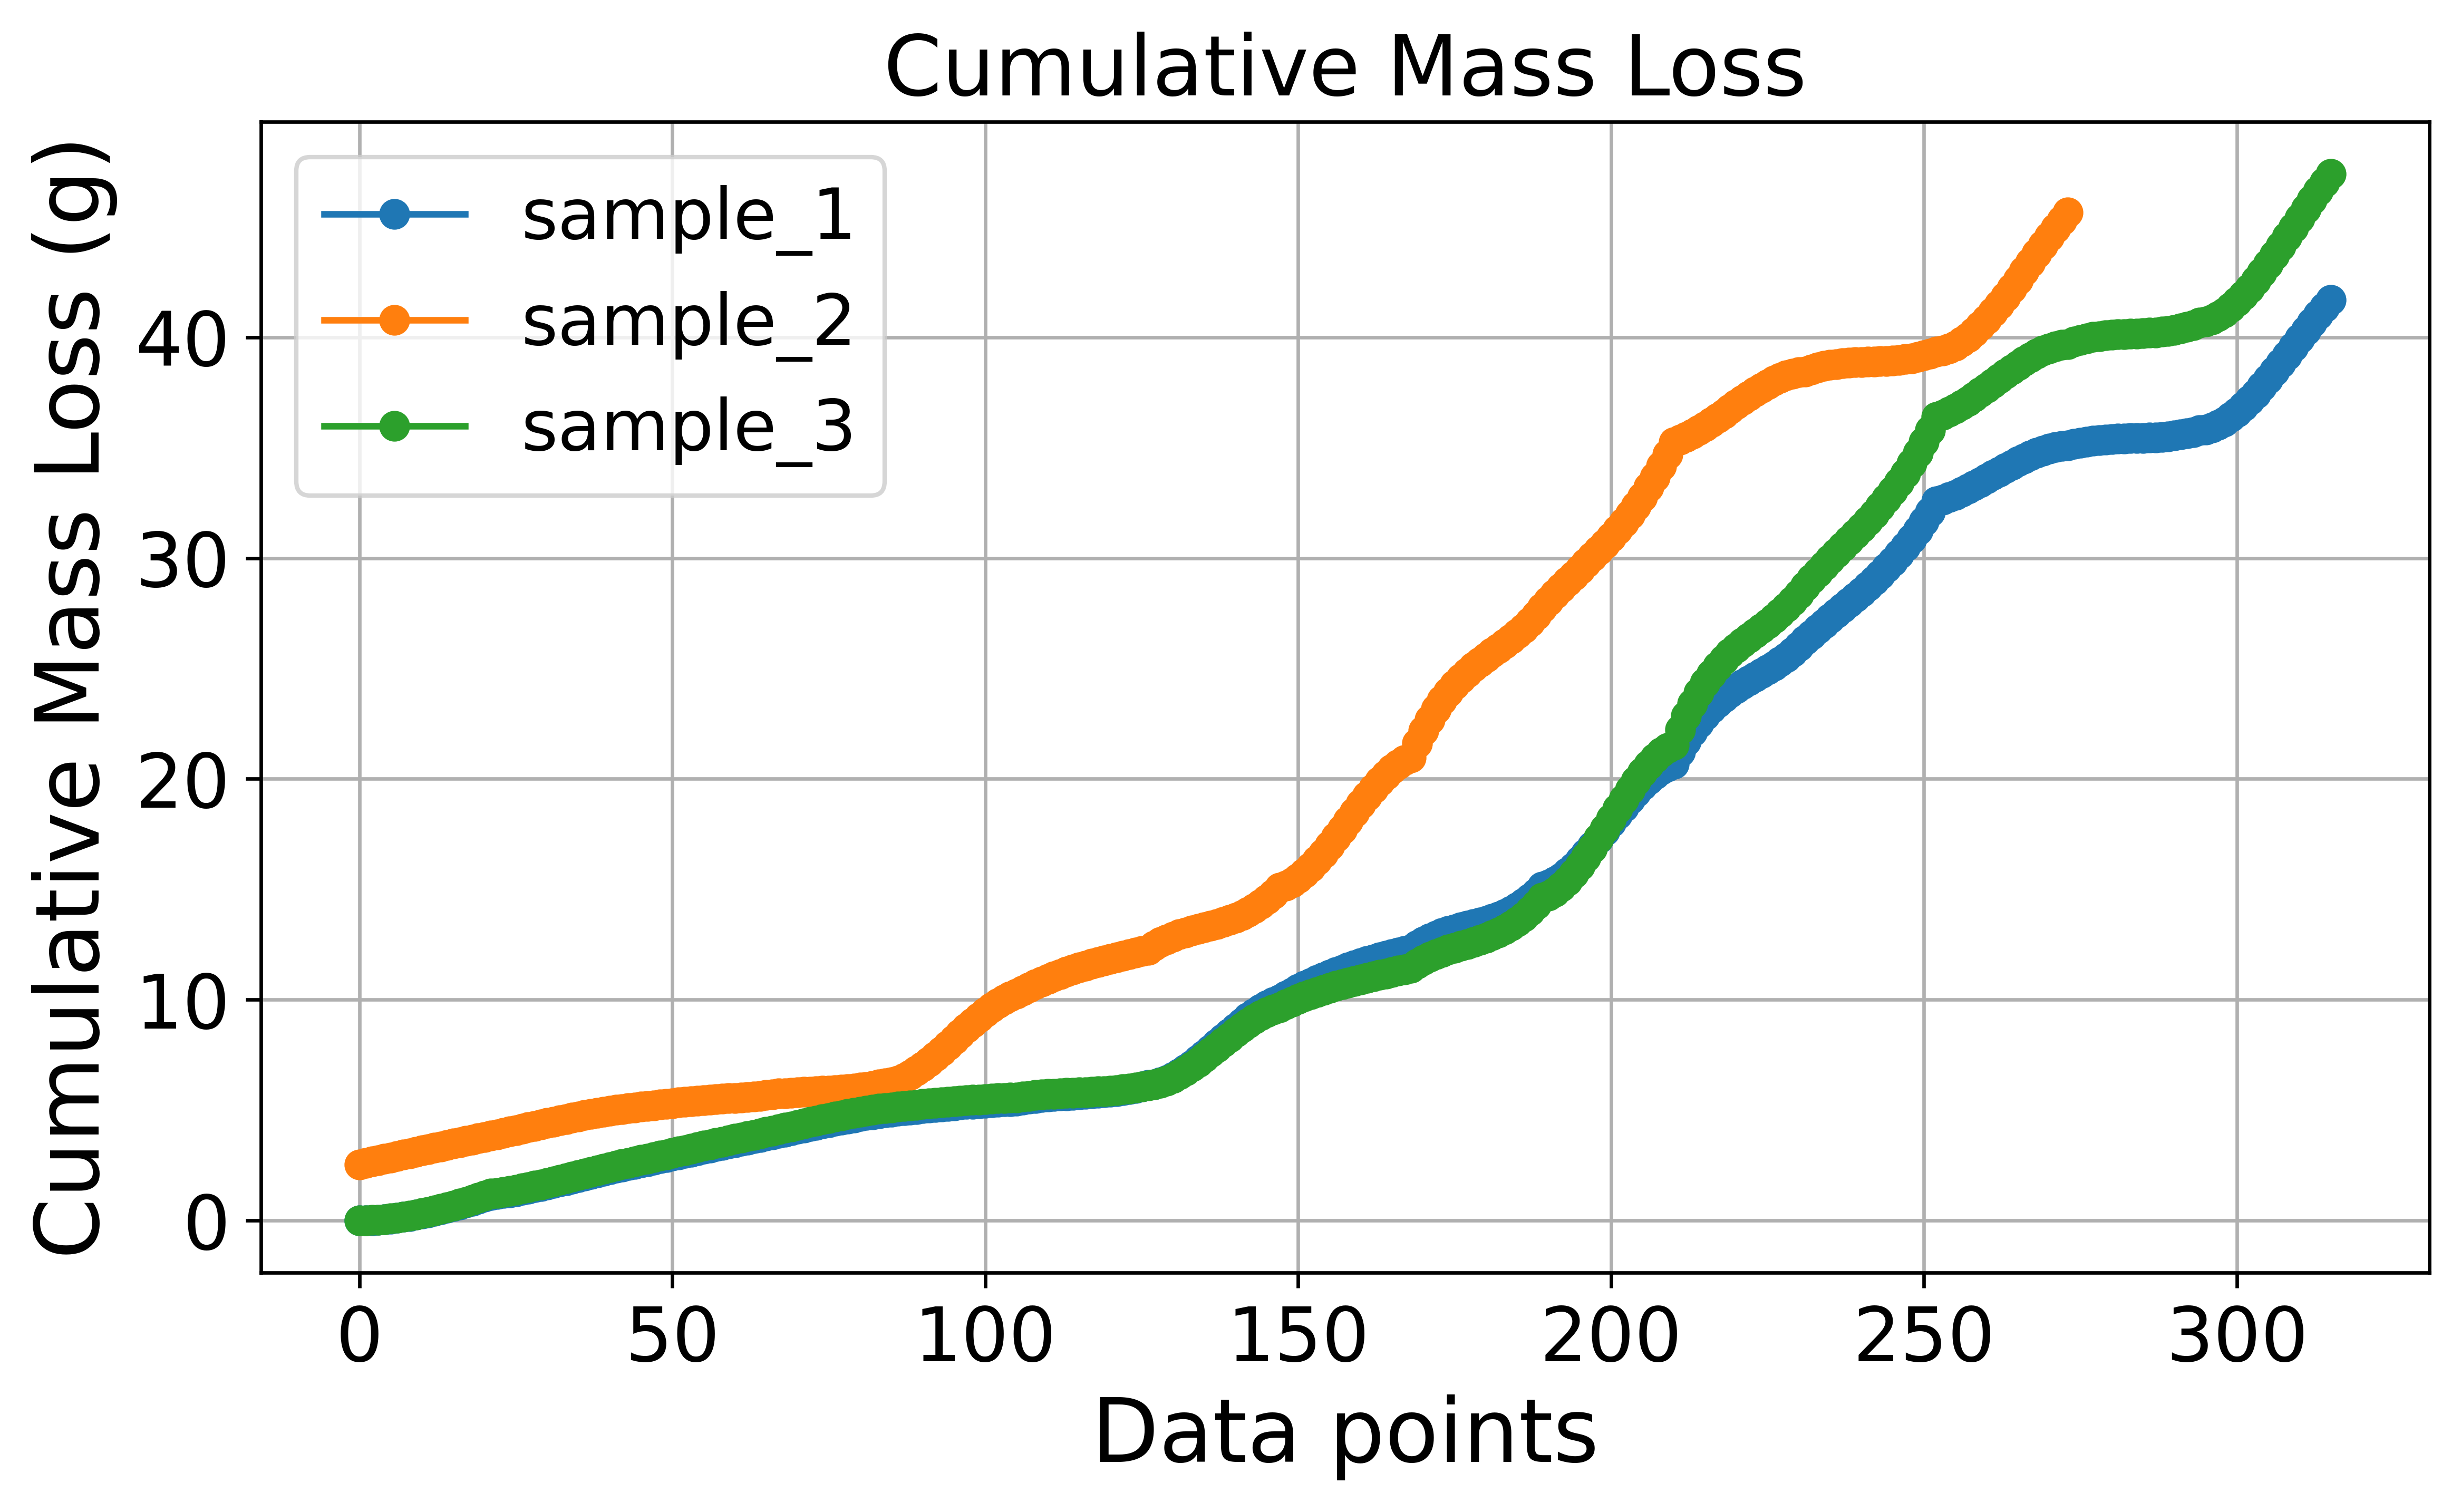

In [25]:
# Load dataset
df = merged_df_eng.copy()

# Convert timestamp to datetime (optional)
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Samples to plot
samples = ["sample_0", "sample_5", "sample_10"]

plt.figure(figsize=(8, 5))

for sample in samples:
    df_sample = df[df["sample"] == sample]
    plt.plot(
        df_sample["Cumulative_Mass_Loss_g_piecewise_cal"].values,
        marker="o"
    )

plt.xlabel("Data points")
plt.ylabel("Cumulative Mass Loss (g)")
plt.title("Cumulative Mass Loss")
plt.grid(True)
plt.legend(["sample_1", "sample_2", "sample_3"])

plt.tight_layout()
plt.show()

# 8. CNN Model Architecture

CNN1D: sliding-window 1-D conv net → Global Avg Pool → FC head → Softplus output.
make_sequences() builds overlapping windows within each sample, never crossing
sample boundaries to prevent temporal leakage.

Input  : (batch, window_size, n_features)
Output : (batch, 1)  — non-negative via Softplus


In [26]:
class CNN1D(nn.Module):
    """
    1-D Convolutional Neural Network for corrosion mass-loss regression.

    Input  : (batch, window_size, n_features)
    Output : (batch, 1)  — non-negative via Softplus

    Architecture
    ------------
    Conv1D × n_conv_layers  (channels double each layer, capped at 256)
        → BatchNorm1d → ReLU → Dropout
    → Global Average Pooling
    → FC(in_ch → fc_dim) → ReLU
    → FC(fc_dim → 1) → Softplus
    """

    def __init__(self, n_features: int, window_size: int,
                 n_filters: int = 32, kernel_size: int = 3,
                 n_conv_layers: int = 2, dropout: float = 0.0):
        super().__init__()
        conv_blocks = []
        in_ch = n_features
        for i in range(n_conv_layers):
            out_ch  = min(n_filters * (2 ** i), 256)
            padding = kernel_size // 2          # 'same' padding
            conv_blocks += [
                nn.Conv1d(in_ch, out_ch, kernel_size, padding=padding),
                nn.BatchNorm1d(out_ch),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            in_ch = out_ch
        self.conv = nn.Sequential(*conv_blocks)
        self.gap  = nn.AdaptiveAvgPool1d(1)     # → (batch, in_ch, 1)
        fc_dim    = max(in_ch // 2, 8)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_ch, fc_dim),
            nn.ReLU(),
            nn.Linear(fc_dim, 1),
            nn.Softplus()
        )
        self._window_size = window_size

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x : (batch, window_size, n_features) → (batch, n_features, window_size)
        x = x.permute(0, 2, 1).contiguous()
        x = self.conv(x)
        x = self.gap(x)
        return self.head(x)


def make_sequences(df: pd.DataFrame,
                   feature_cols: list,
                   target_col: str,
                   window_size: int,
                   sample_col: str = 'sample'):
    """
    Build overlapping sliding-window sequences within each sample.

    Sequences never cross sample boundaries, preventing temporal leakage.

    Parameters
    ----------
    df           : DataFrame with columns [sample_col, 'timestamp',
                   *feature_cols, target_col].  Features should already be
                   scaled before calling this function.
    feature_cols : list of feature column names
    target_col   : regression target column
    window_size  : number of consecutive time steps per window
    sample_col   : column identifying individual physical samples

    Returns
    -------
    X : np.ndarray  (N, window_size, n_features)
    y : np.ndarray  (N,)
    """
    X_parts, y_parts = [], []
    for key in df[sample_col].unique():
        sub = (df[df[sample_col] == key]
               .sort_values('timestamp')
               .reset_index(drop=True))
        Xs = sub[feature_cols].values.astype(np.float32)
        ys = sub[target_col].values.astype(np.float32)
        n  = len(sub)
        if n <= window_size:
            continue
        for i in range(window_size, n):
            X_parts.append(Xs[i - window_size: i])
            y_parts.append(ys[i])
    if not X_parts:
        return (np.empty((0, window_size, len(feature_cols)), dtype=np.float32),
                np.empty(0, dtype=np.float32))
    return (np.stack(X_parts).astype(np.float32),
            np.array(y_parts, dtype=np.float32))



# 9. Training Configuration

FEATURE_COLS              — BVD-derived model inputs
TRAIN_SAMPLES/VAL_SAMPLES — LOO split (one sample held out per fold)

In [27]:
FEATURE_COLS = [
    'rel_R0',
    'rel_R1',
    'rel_L1',
    'rel_C1',
    'rel_C0'
]

TARGET_COL = 'Cumulative_Mass_Loss_g_piecewise_cal'

from sklearn.preprocessing import (
    StandardScaler, QuantileTransformer,
    PowerTransformer, FunctionTransformer,
)

def make_scaler(name: str):
    """Return a scaler by name: 'standard', 'quantile', 'power', or 'none'."""
    if name == 'standard': return StandardScaler()
    if name == 'quantile': return QuantileTransformer(output_distribution='normal')
    if name == 'power':    return PowerTransformer(method='yeo-johnson')
    if name == 'none':     return FunctionTransformer(func=None)
    raise ValueError(f"Unknown scaler: {name}")




# 10. Hyperparameter Search (optional, disabled by default)

A LOO grid search is available in the original notebook (ML_Alt_CNN.ipynb).
Best configuration found:
  scaler=power,  n_filters=16,  kernel_size=5,  n_conv_layers=2,
  dropout=0.1,   window_size=3,  lr=0.1,  wd=0.01
These values are used directly in the training section below.


# 11. LOO Training

In [28]:
import copy
from sklearn.metrics import mean_absolute_error

# ── Training hyperparameters ────────────────────────────────────────────────────────────
N_EPOCHS       = 50000   # maximum epochs (early stopping usually kicks in sooner)
ES_PATIENCE    = 1000    # epochs without improvement before stopping
ES_MIN_DELTA   = 1e-6

LR               = 0.1      # learning rate
WD               = 0.01     # weight decay (L2 regularisation)
best_scaler_type = "power"  # scaler: 'standard', 'quantile', 'power', 'none'
_n_filters       = 16       # initial conv filter count
_kernel_size     = 5        # conv kernel width
_n_conv_layers   = 2        # number of conv blocks
_dropout         = 0.1      # dropout rate
_window_size     = 3        # sliding-window length (time steps)
_loss_fn_name    = 'mse'    # training loss: 'mse' or 'huber'

ALL_SAMPLES = ['sample_0', 'sample_5', 'sample_10']
LOO_FOLDS  = [(sorted(set(ALL_SAMPLES) - {s}), s) for s in ALL_SAMPLES]

fold_results = []   # list of dicts, one per fold

for fold_idx, (train_samps, val_samp) in enumerate(LOO_FOLDS):
    print(f"\n{'='*70}")
    print(f"FOLD {fold_idx+1}/3  |  val: {val_samp}  |  train: {train_samps}")
    print(f"  n_filters={_n_filters}  kernel_size={_kernel_size}  "
          f"n_conv_layers={_n_conv_layers}  dropout={_dropout}  "
          f"window_size={_window_size}  loss_fn={_loss_fn_name}")
    print(f"  scaler={best_scaler_type}  lr={LR:.0e}  wd={WD:.0e}")
    print(f"{'='*70}")

    f_train = merged_df_eng[merged_df_eng['sample'].isin(train_samps)].copy()
    f_val   = merged_df_eng[merged_df_eng['sample'] == val_samp].copy()

    # Scaler fit on training fold only
    sc      = make_scaler(best_scaler_type)
    Xtr_raw = sc.fit_transform(f_train[FEATURE_COLS].values.astype(float))
    Xvl_raw = sc.transform(f_val[FEATURE_COLS].values.astype(float))

    # Inject scaled features for sequence builder
    f_train_s = f_train.copy();  f_train_s[FEATURE_COLS] = Xtr_raw
    f_val_s   = f_val.copy();    f_val_s[FEATURE_COLS]   = Xvl_raw

    Xtr_seq, ytr = make_sequences(f_train_s, FEATURE_COLS, TARGET_COL, _window_size)
    Xvl_seq, yvl = make_sequences(f_val_s,   FEATURE_COLS, TARGET_COL, _window_size)

    print(f"  Train sequences: {len(Xtr_seq)} | Val sequences: {len(Xvl_seq)}")

    # Track which training sequences end on real vs augmented points
    train_is_aug_src = f_train_s.sort_values('timestamp').reset_index(drop=True)
    is_aug_flags = train_is_aug_src['is_augmented'].values \
                   if 'is_augmented' in train_is_aug_src.columns \
                   else np.zeros(len(train_is_aug_src), dtype=bool)
    # A sequence is "augmented" if its terminal time step is augmented
    n = len(train_is_aug_src)
    train_seq_is_aug = np.array([
        is_aug_flags[i] for i in range(_window_size, n)
    ]) if n > _window_size else np.array([], dtype=bool)

    Xtr_t = torch.from_numpy(Xtr_seq)
    ytr_t = torch.tensor(ytr, dtype=torch.float32).unsqueeze(1)
    Xvl_t = torch.from_numpy(Xvl_seq)
    yvl_t = torch.tensor(yvl, dtype=torch.float32).unsqueeze(1)

    torch.manual_seed(42)
    m = CNN1D(n_features=len(FEATURE_COLS), window_size=_window_size,
              n_filters=_n_filters, kernel_size=_kernel_size,
              n_conv_layers=_n_conv_layers, dropout=_dropout)
    optimizer = optim.Adam(m.parameters(), lr=LR, weight_decay=WD)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=800, factor=0.5, min_lr=1e-10)
    mse_fn     = nn.MSELoss()
    train_crit = nn.HuberLoss() if _loss_fn_name == 'huber' else nn.MSELoss()

    fold_history = {'epoch': [], 'train': [], 'val': []}
    best_val     = float('inf')
    best_epoch   = 0
    best_state   = None
    no_improve   = 0

    for epoch in range(1, N_EPOCHS + 1):
        m.train()
        optimizer.zero_grad()
        loss = train_crit(m(Xtr_t), ytr_t)
        loss.backward()
        nn.utils.clip_grad_norm_(m.parameters(), max_norm=1.0)
        optimizer.step()

        m.eval()
        with torch.no_grad():
            val_loss  = mse_fn(m(Xvl_t), yvl_t).item()
            train_mse = mse_fn(m(Xtr_t), ytr_t).item()
        scheduler.step(val_loss)

        if val_loss < best_val - ES_MIN_DELTA:
            best_val   = val_loss
            best_epoch = epoch
            best_state = copy.deepcopy(m.state_dict())
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= ES_PATIENCE:
            print(f"  Early stop @ epoch {epoch}  (best {best_epoch}, val={best_val:.5f})")
            break

        if epoch % 500 == 0 or epoch == 1:
            fold_history['epoch'].append(epoch)
            fold_history['train'].append(train_mse)
            fold_history['val'].append(val_loss)
            print(f"  [{epoch:5d}]  train_mse={train_mse:.5f}  val_mse={val_loss:.5f}  "
                  f"lr={optimizer.param_groups[0]['lr']:.1e}")

    if best_state:
        m.load_state_dict(best_state)
    m.eval()
    with torch.no_grad():
        tr_pred = m(Xtr_t).numpy().flatten()
        vl_pred = m(Xvl_t).numpy().flatten()

    mae = mean_absolute_error(yvl, vl_pred)
    mask_real = ~train_seq_is_aug if len(train_seq_is_aug) == len(tr_pred) else \
                np.ones(len(tr_pred), dtype=bool)
    rmse_tr_real = np.sqrt(np.mean((tr_pred[mask_real] - ytr[mask_real])**2)) \
                   if mask_real.any() else float('nan')
    print(f"  → Fold MAE: {mae:.4f} g  |  Train RMSE (real only): {rmse_tr_real:.4f}")

    fold_results.append({
        'val_sample':    val_samp,
        'train_samps':   train_samps,
        'model':         m,
        'scaler':        sc,
        'window_size':   _window_size,
        'y_train':       ytr,
        'y_val':         yvl,
        'y_tr_pred':     tr_pred,
        'y_vl_pred':     vl_pred,
        'train_is_aug':  train_seq_is_aug if len(train_seq_is_aug) == len(tr_pred)
                         else np.zeros(len(tr_pred), dtype=bool),
        'mae':           mae,
        'history':       fold_history,
    })

# -- Summary -------------------------------------------------------------------
print("\n" + "="*60)
print(f"{'Fold (val sample)':<25} {'Train RMSE':>12} {'Real RMSE':>11} {'Val RMSE':>10} {'MAE':>8}")
print("-"*60)
from sklearn.metrics import mean_squared_error as _mse
for r in fold_results:
    rmse_tr   = np.sqrt(_mse(r['y_train'], r['y_tr_pred']))
    mask_real = ~r['train_is_aug']
    rmse_real = np.sqrt(np.mean((r['y_tr_pred'][mask_real] - r['y_train'][mask_real])**2)) \
                if mask_real.any() else float('nan')
    rmse_vl   = np.sqrt(_mse(r['y_val'], r['y_vl_pred']))
    print(f"  {r['val_sample']:<23} {rmse_tr:>12.4f} {rmse_real:>11.4f} {rmse_vl:>10.4f} {r['mae']:>8.4f}")
avg_mae     = np.mean([r['mae'] for r in fold_results])
avg_rmse_vl = np.mean([np.sqrt(_mse(r['y_val'], r['y_vl_pred'])) for r in fold_results])
print("-"*60)
print(f"  {'Average':<23} {'':>12} {'':>11} {avg_rmse_vl:>10.4f} {avg_mae:>8.4f}")
print("="*60)

# Expose last fold for backward compatibility with downstream cells
_last = fold_results[-1]
model  = _last['model']
scaler = _last['scaler']
y_train = _last['y_train']
y_val   = _last['y_val']
history = {
    'epoch':      _last['history']['epoch'],
    'train_task': _last['history']['train'],
    'train_mono': [0.0] * len(_last['history']['epoch']),
    'train_phys': [0.0] * len(_last['history']['epoch']),
    'val_task':   _last['history']['val'],
}




FOLD 1/3  |  val: sample_0  |  train: ['sample_10', 'sample_5']
  n_filters=16  kernel_size=5  n_conv_layers=2  dropout=0.1  window_size=3  loss_fn=mse
  scaler=power  lr=1e-01  wd=1e-02
  Train sequences: 584 | Val sequences: 313
  [    1]  train_mse=455.56165  val_mse=366.16644  lr=1.0e-01
  [  500]  train_mse=8.94111  val_mse=60.20666  lr=1.0e-01
  [ 1000]  train_mse=12.70531  val_mse=43.24249  lr=1.0e-01
  [ 1500]  train_mse=6.17522  val_mse=96.50363  lr=5.0e-02
  Early stop @ epoch 1697  (best 697, val=14.74505)
  → Fold MAE: 2.6088 g  |  Train RMSE (real only): 4.7004

FOLD 2/3  |  val: sample_5  |  train: ['sample_0', 'sample_10']
  n_filters=16  kernel_size=5  n_conv_layers=2  dropout=0.1  window_size=3  loss_fn=mse
  scaler=power  lr=1e-01  wd=1e-02
  Train sequences: 626 | Val sequences: 271
  [    1]  train_mse=390.79239  val_mse=469.42328  lr=1.0e-01
  [  500]  train_mse=4.21067  val_mse=67.09525  lr=1.0e-01
  [ 1000]  train_mse=9.96393  val_mse=18.43911  lr=1.0e-01
  [ 15

In [29]:
# calculate number of parameters in model
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

n_params = count_parameters(model)
print(f"Model parameters: {n_params:,}")

Model parameters: 3,649



# 12. Evaluate and Plot Result

## ── Figure 1: Parity plots ────────────────────────────────────────

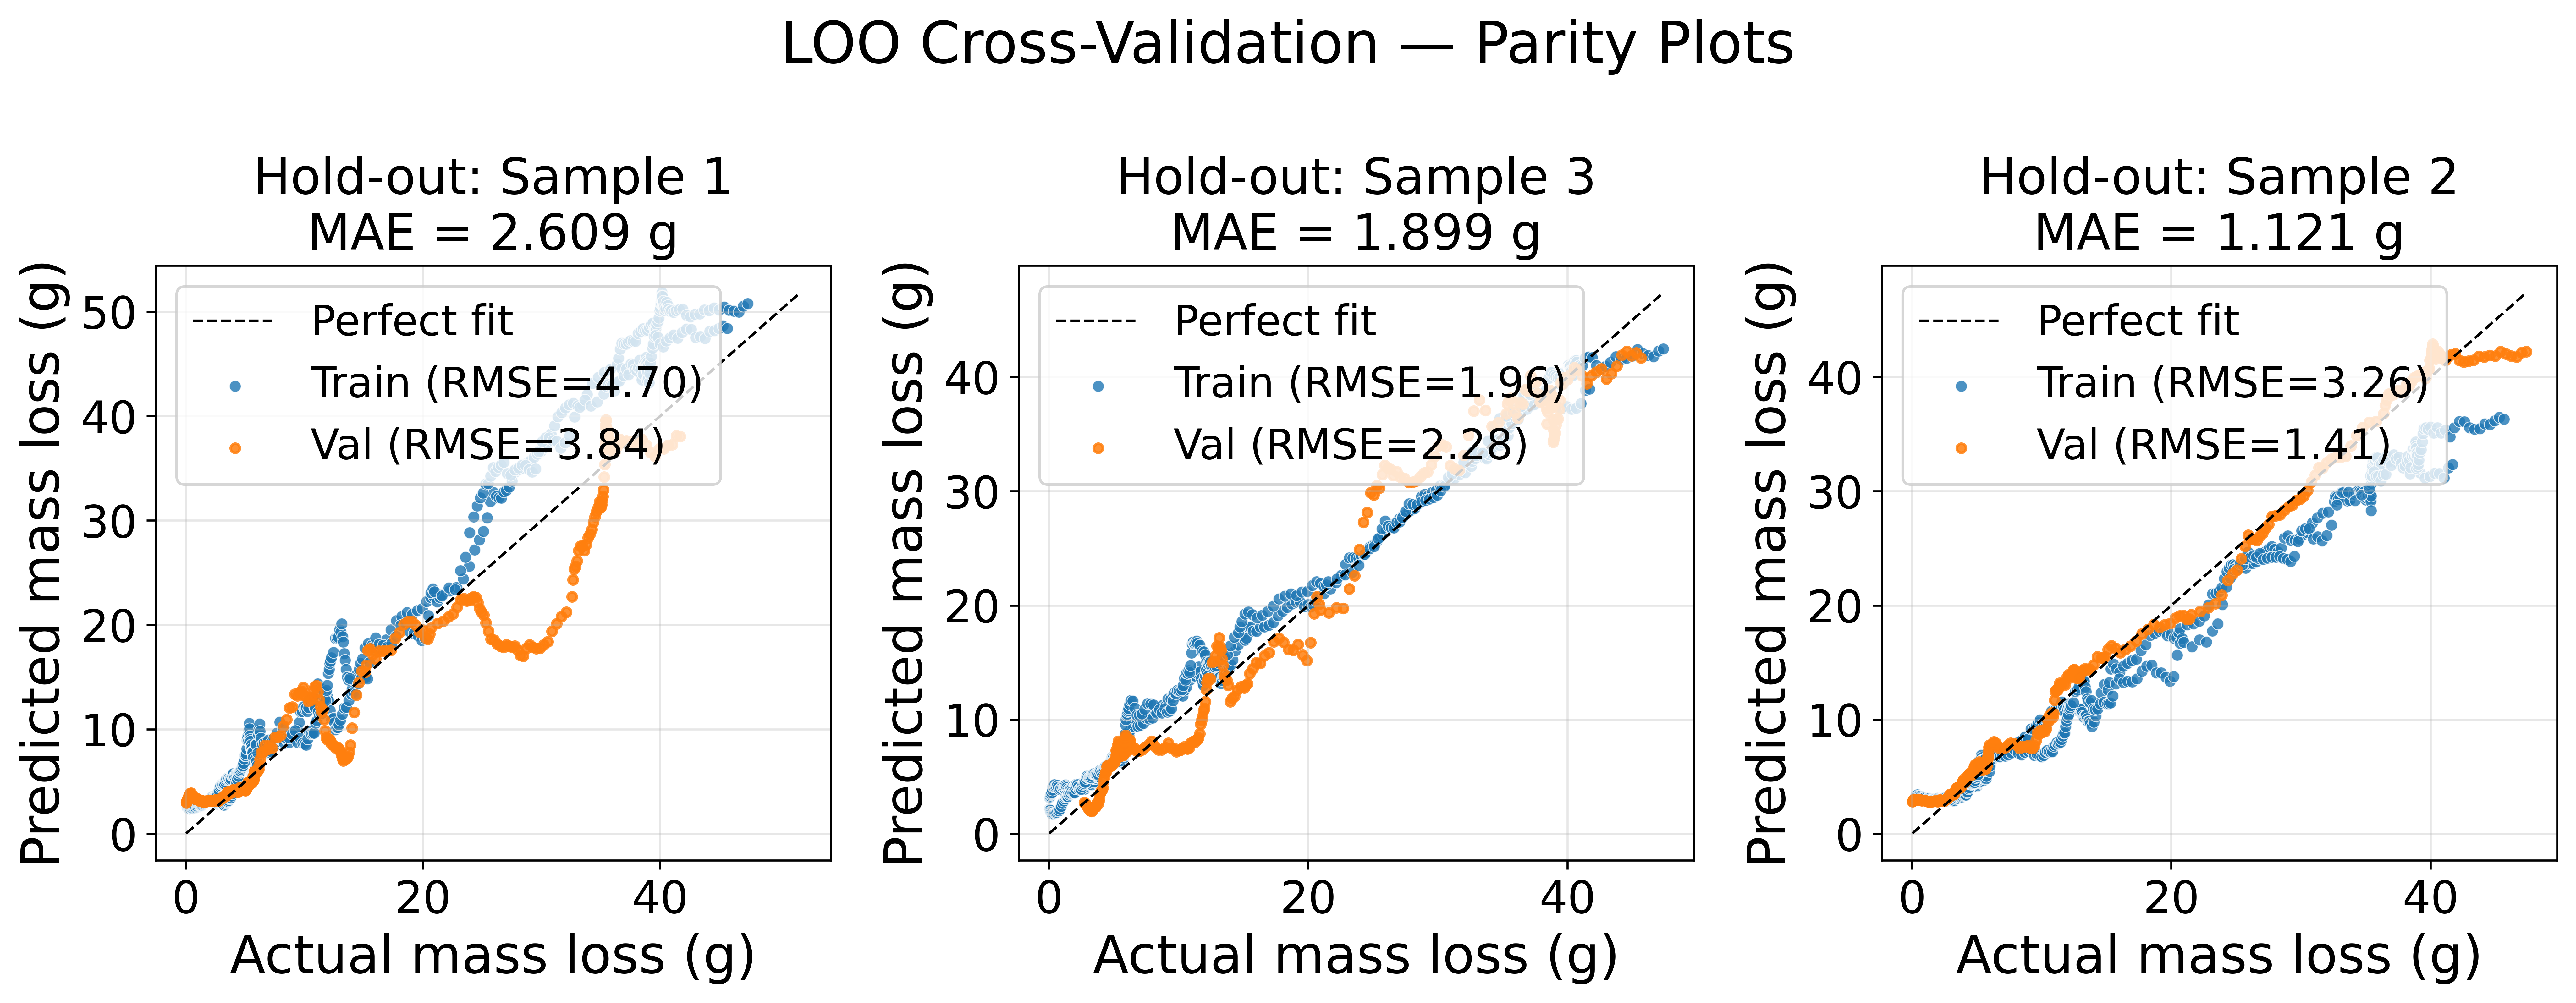


Hold-out sample         Tr RMSE  Tr RMSE(real)   Val RMSE   Val MAE   Val R²
---------------------------------------------------------------------------
  Sample 1               4.7004         4.7004     3.8399    2.6088   0.9118
  Sample 3               1.9595         1.9595     2.2779    1.8990   0.9727
  Sample 2               3.2591         3.2591     1.4117    1.1210   0.9909
---------------------------------------------------------------------------
  Average                                          2.5098    1.8763   0.9585


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

font_scale = 4

plt.rcParams.update({
    'font.size': 14 + font_scale,
    'axes.labelsize': 16 + font_scale,
    'axes.titlesize': 15 + font_scale,
    'xtick.labelsize': 13 + font_scale,
    'ytick.labelsize': 13 + font_scale,
    'legend.fontsize': 12 + font_scale,
    'figure.titlesize': 18 + font_scale,
})

# Human-readable sample labels (adjust if your naming differs)
SAMPLE_LABEL = {
    'sample_0':  'Sample 1',
    'sample_5':  'Sample 3',
    'sample_10': 'Sample 2',
}

fig, axes = plt.subplots(1, 3, figsize=(14, 5.5))

for ax, r in zip(axes, fold_results):
    y_tr_true = r['y_train']
    y_vl_true = r['y_val']
    y_tr_pred = r['y_tr_pred']
    y_vl_pred = r['y_vl_pred']

    is_aug    = r.get('train_is_aug', np.zeros(len(y_tr_true), dtype=bool))
    is_real   = ~is_aug

    rmse_tr_all  = np.sqrt(mean_squared_error(y_tr_true, y_tr_pred))
    rmse_tr_real = np.sqrt(np.mean((y_tr_pred[is_real] - y_tr_true[is_real])**2)) \
                   if is_real.any() else float('nan')
    rmse_vl      = np.sqrt(mean_squared_error(y_vl_true, y_vl_pred))
    mae_vl       = mean_absolute_error(y_vl_true, y_vl_pred)

    y_all = np.concatenate([y_tr_true, y_vl_true, y_tr_pred, y_vl_pred])
    y_min, y_max = y_all.min(), y_all.max()

    ax.plot([y_min, y_max], [y_min, y_max], 'k--', lw=1, label='Perfect fit')
    if is_aug.any():
        ax.scatter(y_tr_true[is_aug], y_tr_pred[is_aug], s=4, alpha=0.25,
                   color='tab:blue', label=f'Train aug (RMSE={rmse_tr_all:.2f})')
    if is_real.any():
        ax.scatter(y_tr_true[is_real], y_tr_pred[is_real], s=20, alpha=0.8,
                   color='tab:blue', edgecolors='white', linewidths=0.3,
                   label=f'Train (RMSE={rmse_tr_real:.2f})')
    ax.scatter(y_vl_true, y_vl_pred, s=12, alpha=0.85, color='tab:orange',
               label=f'Val (RMSE={rmse_vl:.2f})')

    label = SAMPLE_LABEL.get(r['val_sample'], r['val_sample'])
    ax.set_title(f'Hold-out: {label}\nMAE = {mae_vl:.3f} g')
    ax.set_xlabel('Actual mass loss (g)')
    ax.set_ylabel('Predicted mass loss (g)')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

plt.suptitle('LOO Cross-Validation — Parity Plots')
plt.tight_layout()
plt.show()

# ── Summary table (with R²) ────────────────────────────────────────────────────
print(f"\n{'Hold-out sample':<20} {'Tr RMSE':>10} {'Tr RMSE(real)':>14} {'Val RMSE':>10} {'Val MAE':>9} {'Val R²':>8}")
print("-" * 75)
for r in fold_results:
    label     = SAMPLE_LABEL.get(r['val_sample'], r['val_sample'])
    is_real   = ~r.get('train_is_aug', np.zeros(len(r['y_train']), dtype=bool))
    rmse_tr   = np.sqrt(mean_squared_error(r['y_train'], r['y_tr_pred']))
    rmse_tr_r = np.sqrt(np.mean((r['y_tr_pred'][is_real] - r['y_train'][is_real])**2)) \
                if is_real.any() else float('nan')
    rmse_vl   = np.sqrt(mean_squared_error(r['y_val'], r['y_vl_pred']))
    r2_vl     = r2_score(r['y_val'], r['y_vl_pred'])
    print(f"  {label:<18} {rmse_tr:>10.4f} {rmse_tr_r:>14.4f} {rmse_vl:>10.4f} {r['mae']:>9.4f} {r2_vl:>8.4f}")
avg_mae     = np.mean([r['mae'] for r in fold_results])
avg_rmse_vl = np.mean([np.sqrt(mean_squared_error(r['y_val'], r['y_vl_pred'])) for r in fold_results])
avg_r2_vl   = np.mean([r2_score(r['y_val'], r['y_vl_pred']) for r in fold_results])
print("-" * 75)
print(f"  {'Average':<18} {'':>10} {'':>14} {avg_rmse_vl:>10.4f} {avg_mae:>9.4f} {avg_r2_vl:>8.4f}")

# ── Bootstrap over time points ─────────────────────────────────────────────────
N_BOOT = 1000
rng_boot = np.random.default_rng(0)

boot_stats = []   # one dict per fold

for r in fold_results:
    yt = r['y_val']
    yp = r['y_vl_pred']
    n  = len(yt)

    boot_rmse = np.empty(N_BOOT)
    boot_r2   = np.empty(N_BOOT)
    boot_mae  = np.empty(N_BOOT)

    for b in range(N_BOOT):
        idx = rng_boot.integers(0, n, size=n)
        boot_rmse[b] = np.sqrt(np.mean((yp[idx] - yt[idx])**2))
        boot_r2[b]   = r2_score(yt[idx], yp[idx])
        boot_mae[b]  = np.mean(np.abs(yp[idx] - yt[idx]))

    boot_stats.append({
        'label':     SAMPLE_LABEL.get(r['val_sample'], r['val_sample']),
        'rmse':      boot_rmse,
        'r2':        boot_r2,
        'mae':       boot_mae,
        'rmse_mean': boot_rmse.mean(),
        'rmse_std':  boot_rmse.std(),
        'rmse_ci95': np.percentile(boot_rmse, [2.5, 97.5]),
        'r2_mean':   boot_r2.mean(),
        'r2_std':    boot_r2.std(),
        'r2_ci95':   np.percentile(boot_r2, [2.5, 97.5]),
    })


## ── Figure 2: Bootstrap RMSE & R² distributions ───────────────────────────────

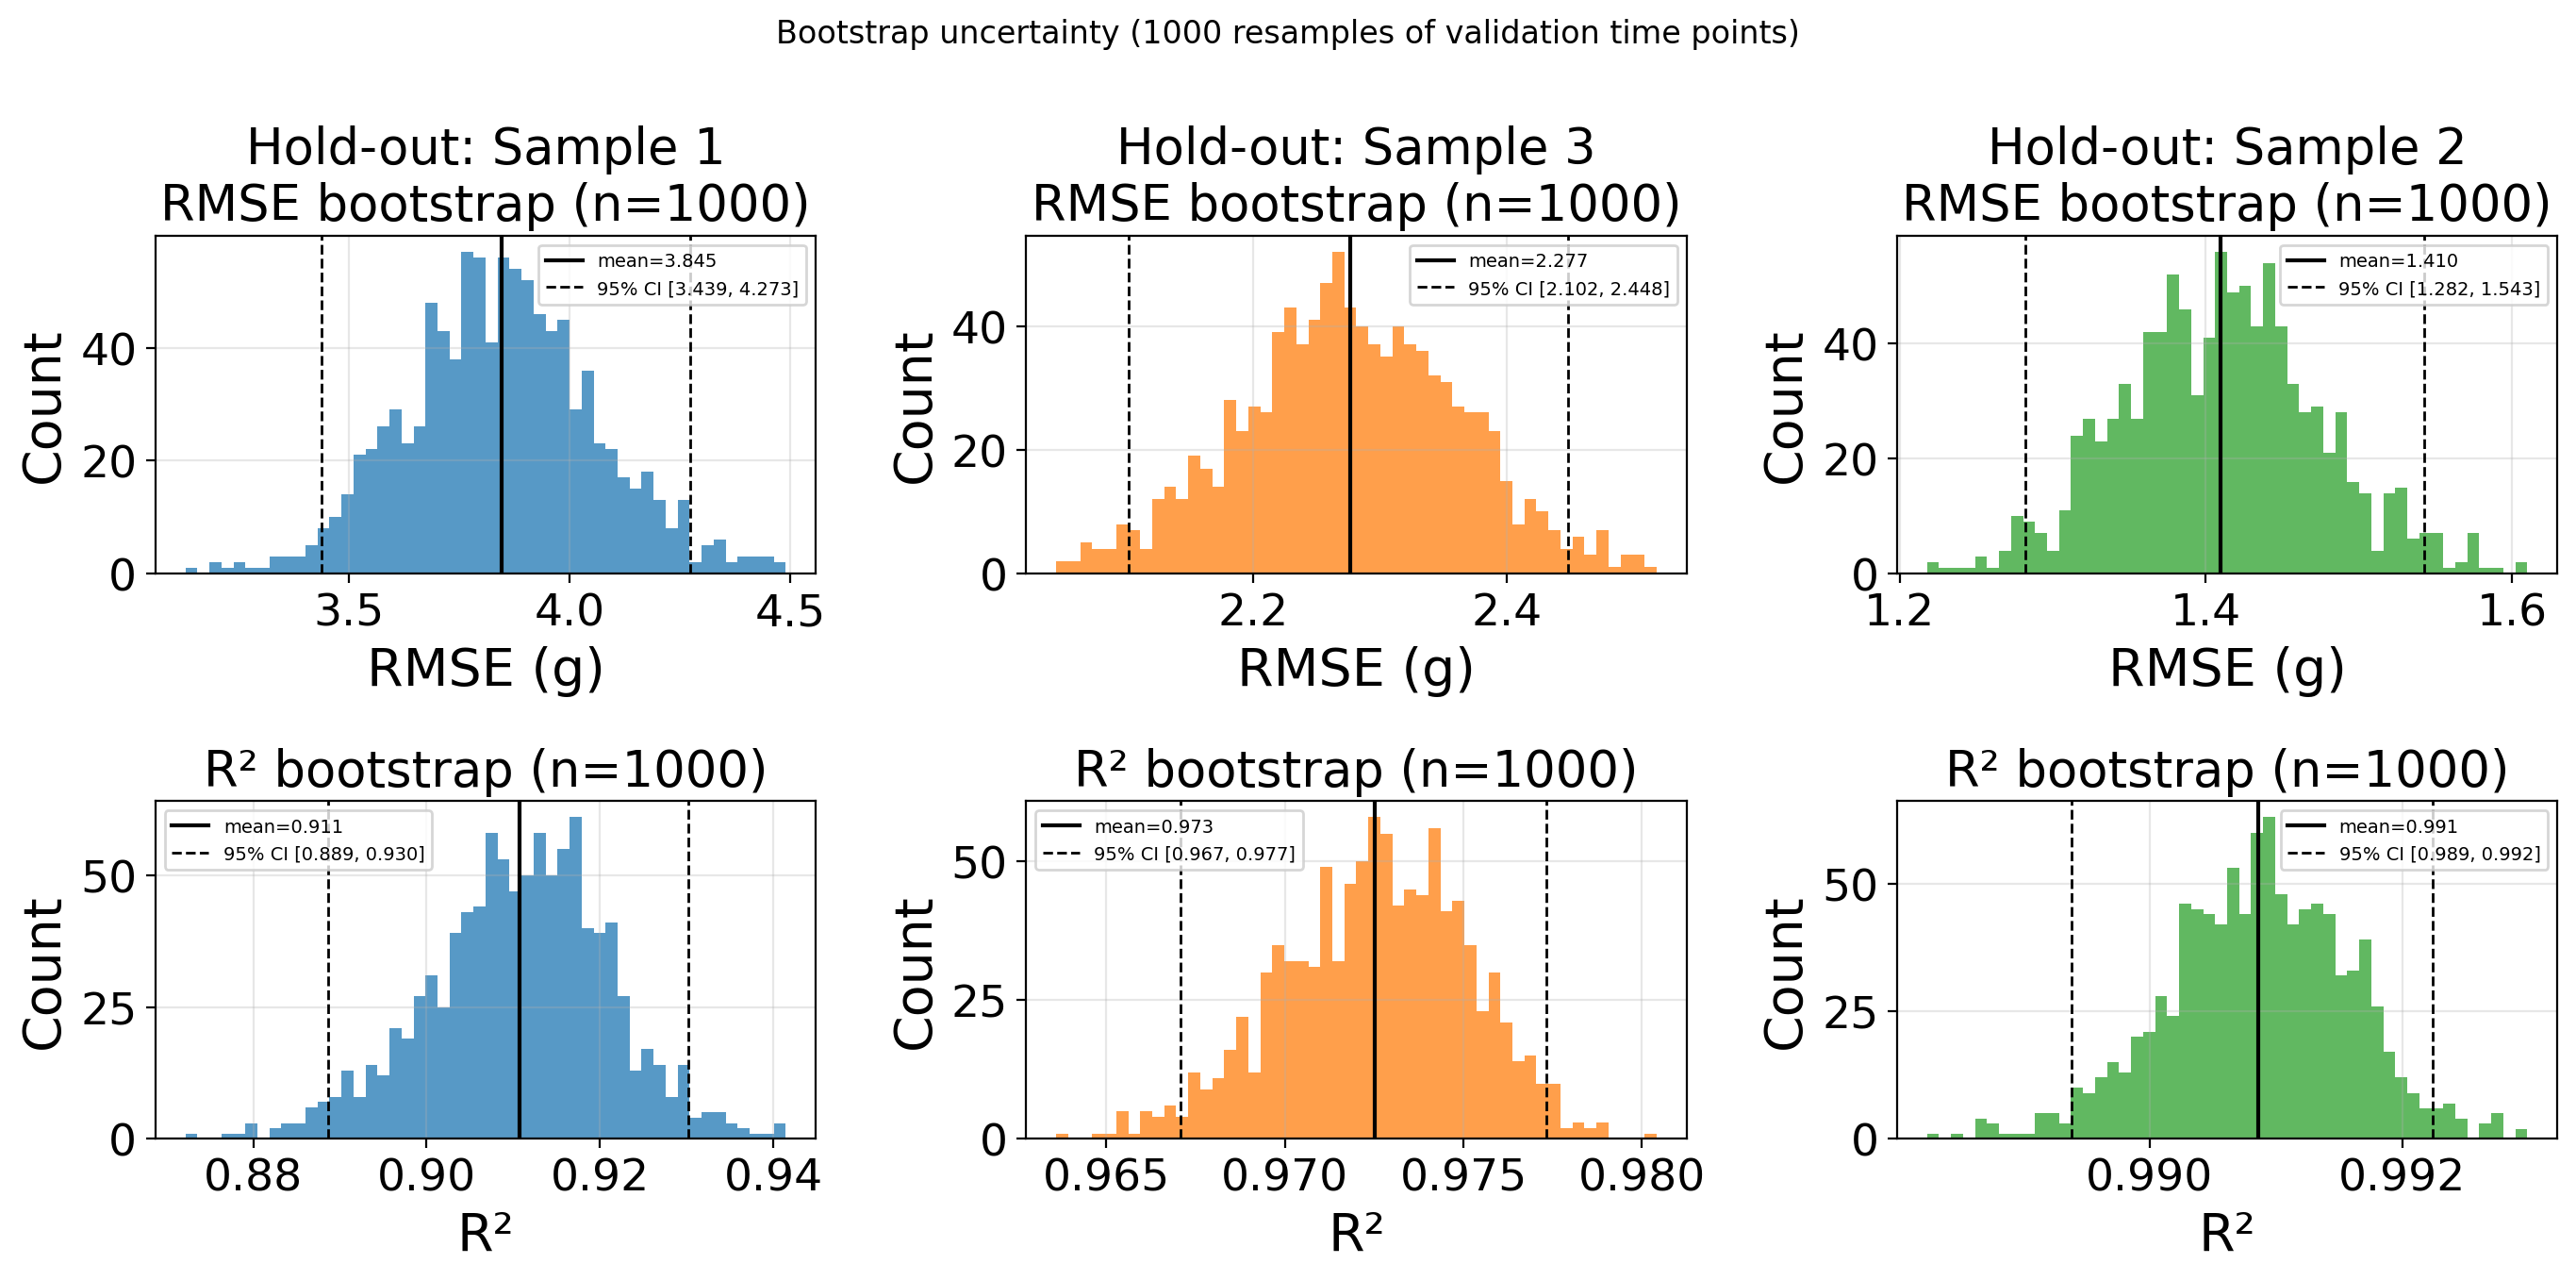

In [31]:
fig2, axes2 = plt.subplots(2, 3, figsize=(14, 7), dpi=200)
colors_fold = ['tab:blue', 'tab:orange', 'tab:green']

for col, (bs, color) in enumerate(zip(boot_stats, colors_fold)):
    # Top row: RMSE distribution
    ax = axes2[0, col]
    ax.hist(bs['rmse'], bins=50, color=color, alpha=0.75, edgecolor='none')
    lo, hi = bs['rmse_ci95']
    ax.axvline(bs['rmse_mean'], color='k',      lw=1.5, label=f"mean={bs['rmse_mean']:.3f}")
    ax.axvline(lo,              color='k',      lw=1,   linestyle='--', label=f"95% CI [{lo:.3f}, {hi:.3f}]")
    ax.axvline(hi,              color='k',      lw=1,   linestyle='--')
    ax.set_title(f"Hold-out: {bs['label']}\nRMSE bootstrap (n={N_BOOT})")
    ax.set_xlabel('RMSE (g)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

    # Bottom row: R² distribution
    ax = axes2[1, col]
    ax.hist(bs['r2'], bins=50, color=color, alpha=0.75, edgecolor='none')
    lo2, hi2 = bs['r2_ci95']
    ax.axvline(bs['r2_mean'], color='k', lw=1.5, label=f"mean={bs['r2_mean']:.3f}")
    ax.axvline(lo2,           color='k', lw=1,   linestyle='--', label=f"95% CI [{lo2:.3f}, {hi2:.3f}]")
    ax.axvline(hi2,           color='k', lw=1,   linestyle='--')
    ax.set_title(f"R² bootstrap (n={N_BOOT})")
    ax.set_xlabel('R²')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Bootstrap uncertainty ({N_BOOT} resamples of validation time points)', fontsize=12)
plt.tight_layout()
plt.show()

## ── Figure 3: RMSE variance per fold (bar chart with CI error bars) ────────────

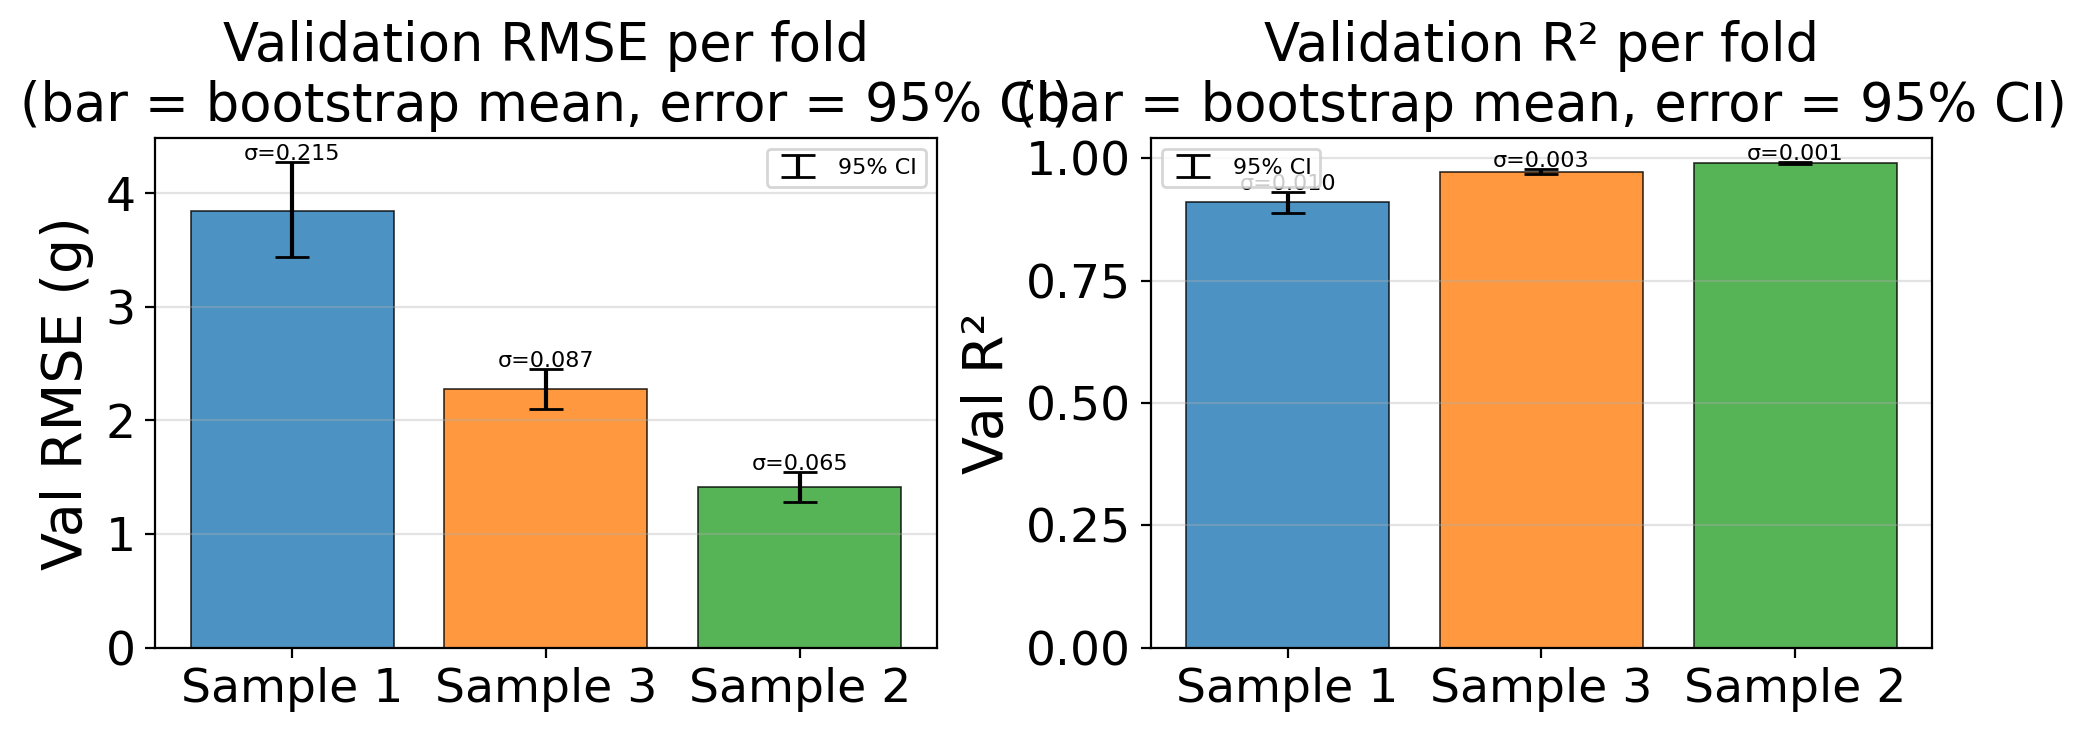


Hold-out         RMSE mean   RMSE std        RMSE 95% CI   R² mean   R² std         R² 95% CI
---------------------------------------------------------------------------------------------
  Sample 1          3.8454     0.2153   [3.4388, 4.2729]      0.9107   0.0105  [0.8886, 0.9302]
  Sample 3          2.2769     0.0867   [2.1017, 2.4485]      0.9725   0.0026  [0.9671, 0.9773]
  Sample 2          1.4098     0.0648   [1.2822, 1.5428]      0.9909   0.0007  [0.9894, 0.9922]


In [32]:

labels_list  = [bs['label']    for bs in boot_stats]
rmse_means   = [bs['rmse_mean'] for bs in boot_stats]
rmse_stds    = [bs['rmse_std']  for bs in boot_stats]
rmse_ci_lo   = [bs['rmse_mean'] - bs['rmse_ci95'][0] for bs in boot_stats]
rmse_ci_hi   = [bs['rmse_ci95'][1] - bs['rmse_mean'] for bs in boot_stats]
r2_means     = [bs['r2_mean']  for bs in boot_stats]
r2_stds      = [bs['r2_std']   for bs in boot_stats]
r2_ci_lo     = [bs['r2_mean'] - bs['r2_ci95'][0] for bs in boot_stats]
r2_ci_hi     = [bs['r2_ci95'][1] - bs['r2_mean'] for bs in boot_stats]

x = np.arange(len(labels_list))

fig3, (ax_r, ax_r2) = plt.subplots(1, 2, figsize=(10, 4), dpi=200)

bars = ax_r.bar(x, rmse_means, color=colors_fold, alpha=0.8, edgecolor='k', linewidth=0.6)
ax_r.errorbar(x, rmse_means,
              yerr=[rmse_ci_lo, rmse_ci_hi],
              fmt='none', color='k', capsize=6, lw=1.5, label='95% CI')
ax_r.set_xticks(x); ax_r.set_xticklabels(labels_list)
ax_r.set_ylabel('Val RMSE (g)')
ax_r.set_title('Validation RMSE per fold\n(bar = bootstrap mean, error = 95% CI)')
ax_r.legend(fontsize=8)
ax_r.grid(True, axis='y', alpha=0.35)
# Annotate std
for xi, (mean, std) in enumerate(zip(rmse_means, rmse_stds)):
    ax_r.text(xi, mean + rmse_ci_hi[xi] + 0.02, f'σ={std:.3f}', ha='center', fontsize=8)

bars2 = ax_r2.bar(x, r2_means, color=colors_fold, alpha=0.8, edgecolor='k', linewidth=0.6)
ax_r2.errorbar(x, r2_means,
               yerr=[r2_ci_lo, r2_ci_hi],
               fmt='none', color='k', capsize=6, lw=1.5, label='95% CI')
ax_r2.set_xticks(x); ax_r2.set_xticklabels(labels_list)
ax_r2.set_ylabel('Val R²')
ax_r2.set_title('Validation R² per fold\n(bar = bootstrap mean, error = 95% CI)')
ax_r2.legend(fontsize=8)
ax_r2.grid(True, axis='y', alpha=0.35)
for xi, (mean, std) in enumerate(zip(r2_means, r2_stds)):
    ax_r2.text(xi, mean + r2_ci_hi[xi] + 0.005, f'σ={std:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

# ── Bootstrap summary table ────────────────────────────────────────────────────
print(f"\n{'Hold-out':<14} {'RMSE mean':>11} {'RMSE std':>10} {'RMSE 95% CI':>18} "
      f"{'R² mean':>9} {'R² std':>8} {'R² 95% CI':>17}")
print("-" * 93)
for bs in boot_stats:
    lo_r,  hi_r  = bs['rmse_ci95']
    lo_r2, hi_r2 = bs['r2_ci95']
    print(f"  {bs['label']:<12} {bs['rmse_mean']:>11.4f} {bs['rmse_std']:>10.4f} "
          f"  [{lo_r:.4f}, {hi_r:.4f}]   "
          f"{bs['r2_mean']:>9.4f} {bs['r2_std']:>8.4f}  [{lo_r2:.4f}, {hi_r2:.4f}]")